In [195]:
using NBInclude
@nbinclude("etd_euler.ipynb")
@nbinclude("etd_rk2.ipynb")
@nbinclude("etd_rk3.ipynb")
@nbinclude("etd_rk4.ipynb")
@nbinclude("../set_makie_defaults.ipynb")
@nbinclude("plotting_utils.ipynb")

plot_sol_2D (generic function with 3 methods)

In [32]:
discrete_lp_norm(u, Δt; p = 2)  = norm(u,p) * (Δt)^(1/p)

discrete_lp_norm (generic function with 1 method)

### Scalar Test ODE: 

##### **ODE: $\displaystyle u' = -au + u^2, \quad u(0) = u_0, \quad 0 < u_0 < a$**

##### **Exact Solution:**  $\quad \displaystyle u(t) = \frac{a}{1 - \left(1 - \frac{a}{u_0} \right)e^t}$

- We have $A = -a$ and $f(u,t) = u^2$
- Note that $\lim\limits_{t \to \infty} u(t) = 0$, provided $a > 0$. 

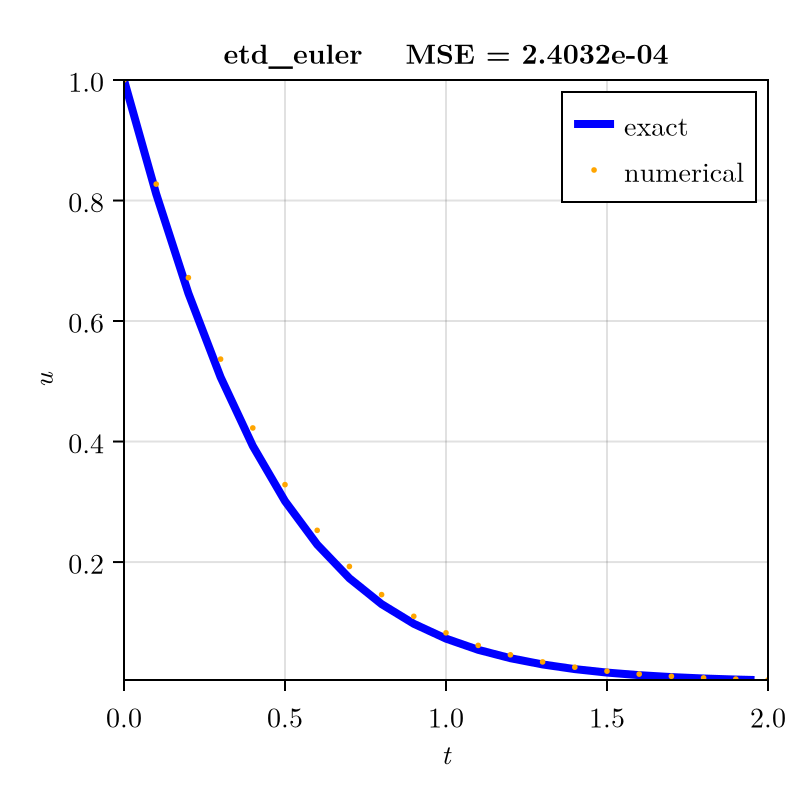

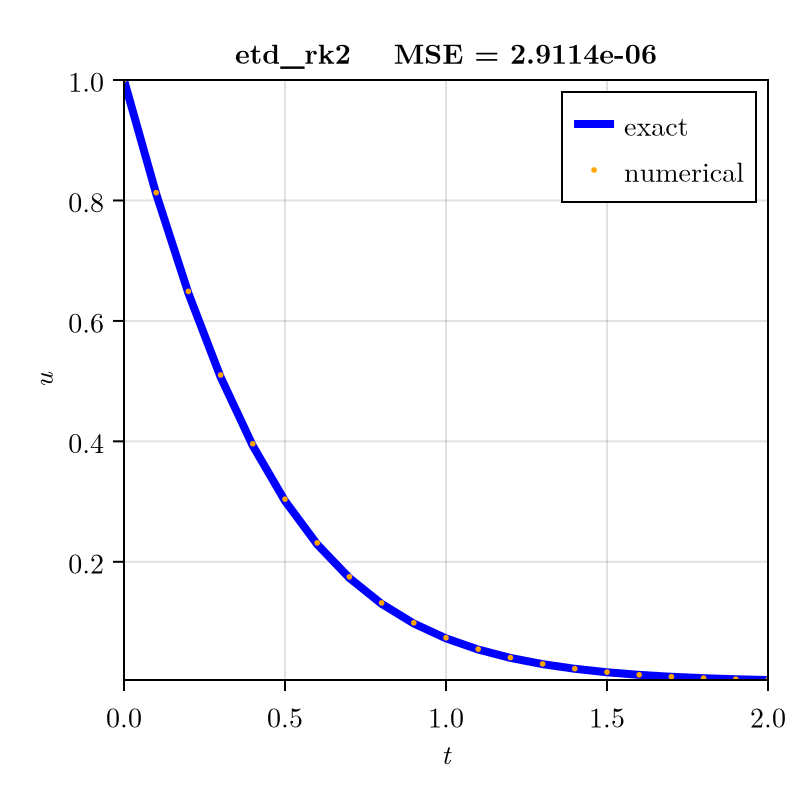

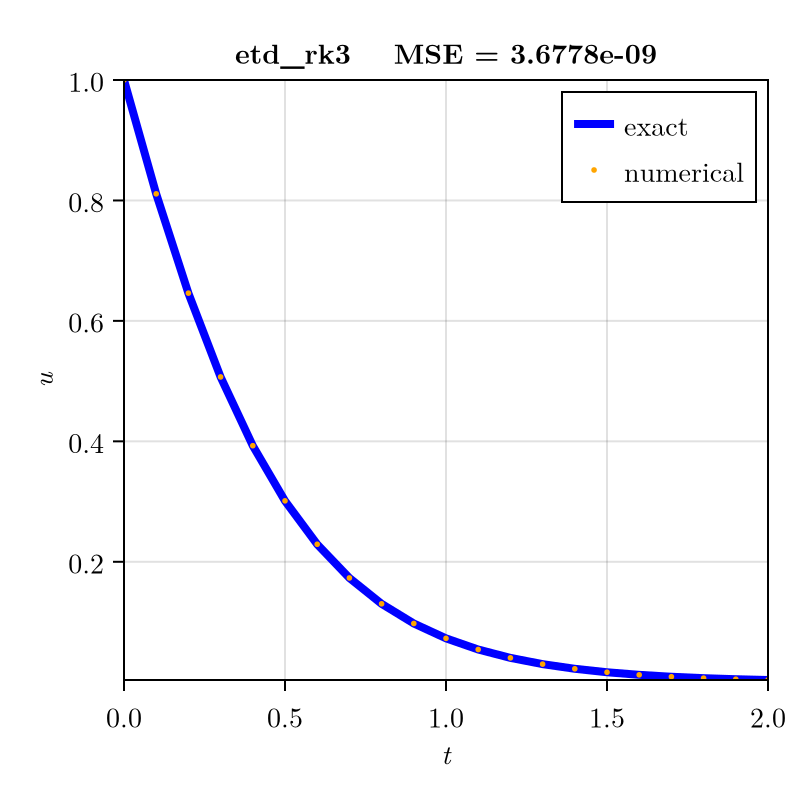

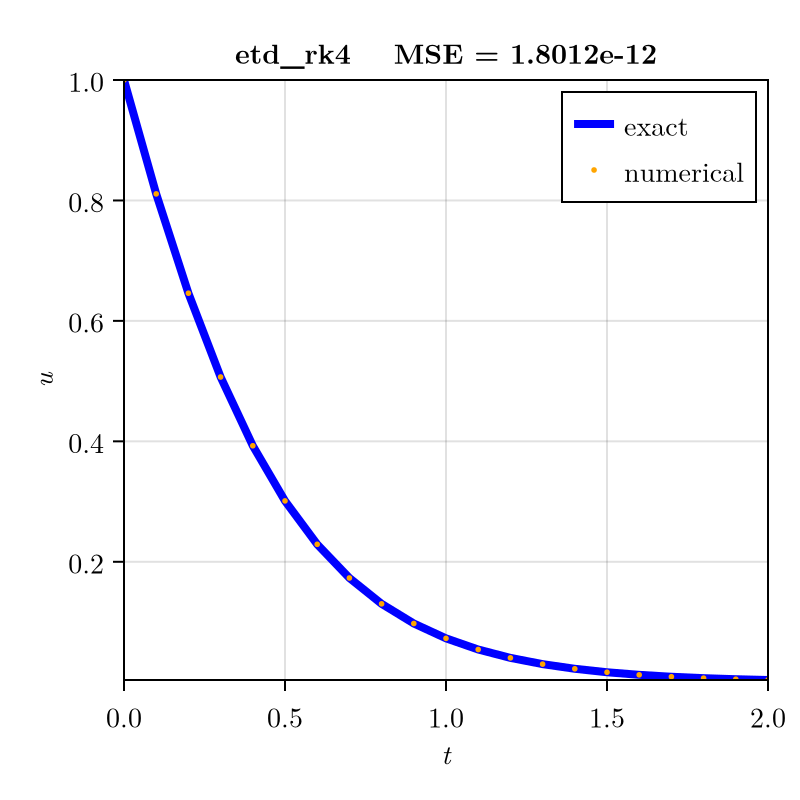

In [55]:
#Test ETD Euler using a *scalar* equation
a = 3.0 
u0 = 1.0 

Δt = 0.01
tf = 2.0 
u_exact_scalar(t,a,u0) = a ./ (1.0 - (1.0 - a/u0)*exp(a*t))

A = -a 
f(u,p,t) = u^2 

for solver in [etd_euler, etd_rk2, etd_rk3, etd_rk4]

    sol = solver(A, f, u0; Δt = 0.1, tspan = (0,tf), p = nothing, ϵ = 1e-3)
    
    @unpack u, t, Δt = sol
    u_num = u 
    u_ex = u_exact_scalar.(t, a, u0)
    
    title_str = string(nameof(solver)) * @sprintf("    MSE = %.4e", mean((u_num .- u_ex).^2))
    plot_sol_1D(u_num, t; u_ex, size = (400,400), title = title_str, markersize = 4, linewidth = 4, legend_pos = :rt) 
end

#### **Vector Test ODE** 
$$A = \begin{pmatrix} -100 & \phantom{-}0 \\ 0 & -1 \end{pmatrix}, \quad F(\mathbf{u},p,t) = \begin{pmatrix} \cos t + 100 \sin t + u_1^2 - \sin^2 t \\ - \sin t + \cos t + u_1 u_2 - \sin t \cos t \end{pmatrix}, \quad \mathbf{u}(0) = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

#### **Exact solution:** $$\mathbf{u}(t) = \begin{pmatrix} u_1(t) \\ u_2(t) \end{pmatrix} = \begin{pmatrix} \sin t \\ \cos t \end{pmatrix}$$



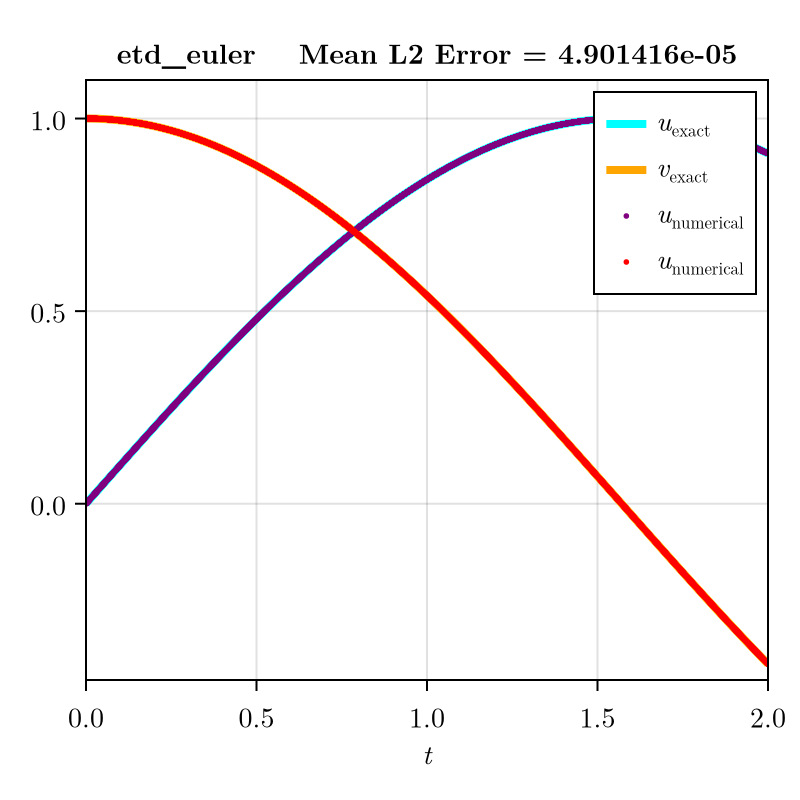

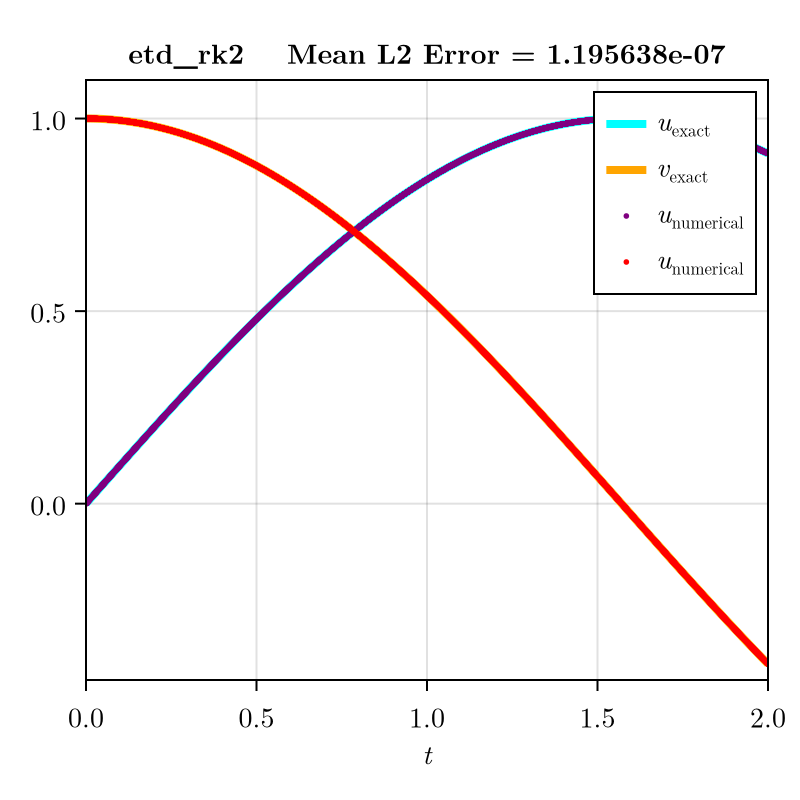

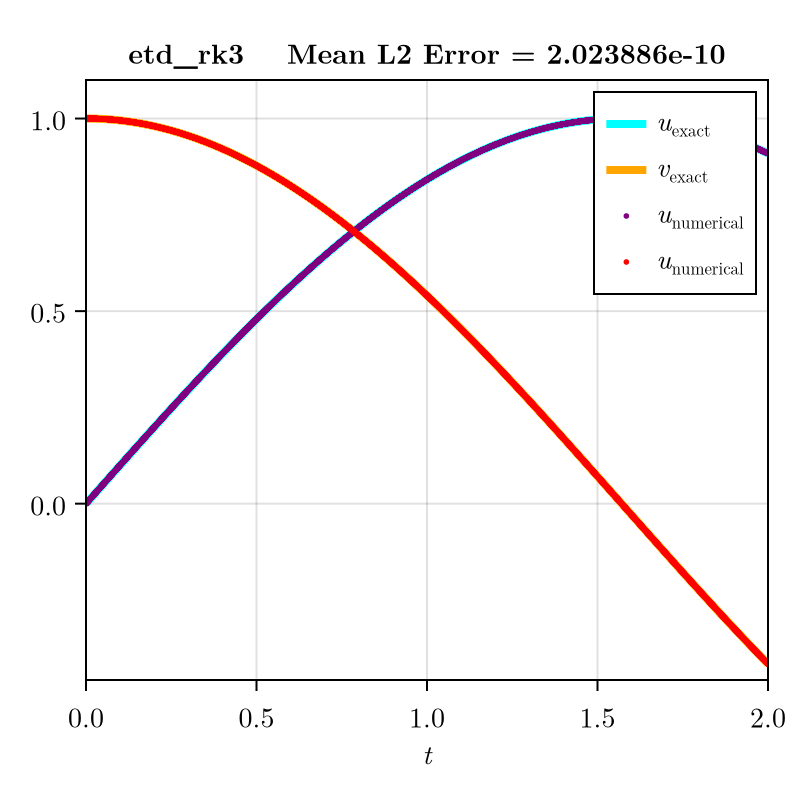

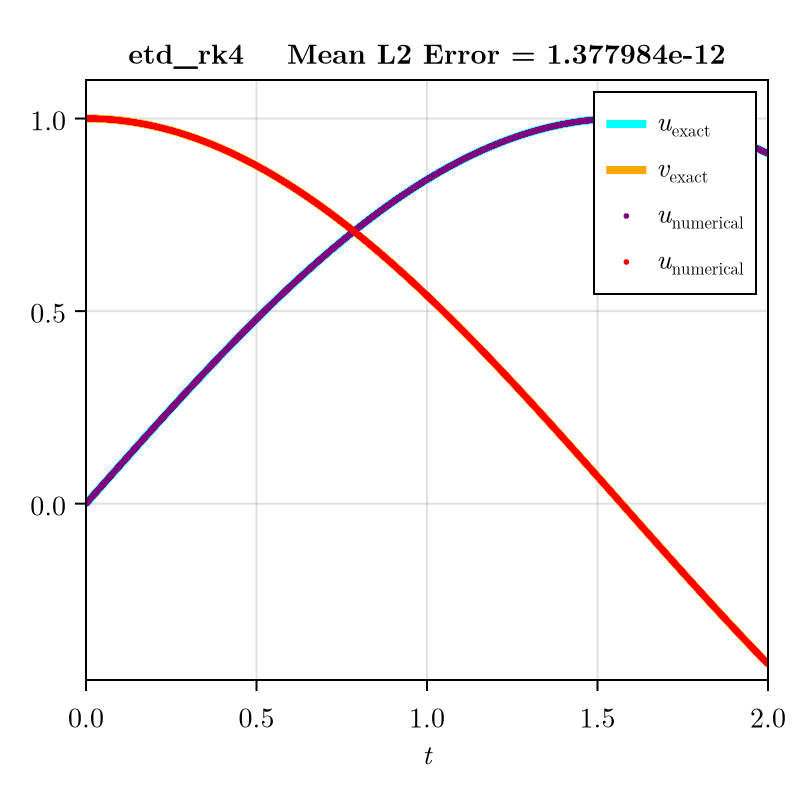

In [228]:
function f(u,p,t)
    f1 = cos(t) + 100*sin(t) + (u[1])^2 - (sin(t))^2 
    f2 = -sin(t) + cos(t) + u[1] * u[2] - sin(t) * cos(t)
    return [f1, f2]
end 

u_exact(t) = [sin(t), cos(t)]

A = [-100.0 0.0; 0.0 -1.0]
u0 = [0.0, 1.0]

#Test ETD Euler using a *scalar* equation
for solver in [etd_euler, etd_rk2, etd_rk3, etd_rk4]

    sol = solver(A, f, u0; Δt = 0.0001, tspan = (0,tf), p = nothing, ϵ = 1e-3)

    t = sol.t
    U_num = sol.u
    U_exact = u_exact.(t)

    l2_errors = [norm(U_num[i] - U_exact[i]) for i=1:length(U_num)]
    mean_l2_err = mean(l2_errors)
    
    title_str = string(nameof(solver)) * @sprintf("    Mean L2 Error = %.6e", mean_l2_err)
    plot_sol_2D(U_num, t; U_exact = U_exact, size = (400,400),  title = title_str, markersize = 4, linewidth = 4)
end